# W2 D25 — PCA & Dimensionality Reduction
**Topics:** sklearn Breast Cancer | PCA, explained variance, biplot, reconstruction error

**Q1** EDA — feature correlations heatmap
**Q2** PCA — scree plot & cumulative variance
**Q3** 2D PCA scatter colored by diagnosis
**Q4** Biplot — feature loadings
**Q5** Classification with raw vs PCA features


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings('ignore')
np.random.seed(420)
print('Libraries loaded')

Libraries loaded


In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['target'] = data.target  # 0=malignant, 1=benign
df['diagnosis'] = df['target'].map({0:'Malignant', 1:'Benign'})
X = data.data
y = data.target
print(f'Breast cancer dataset: {X.shape}  |  Benign={y.sum()}  Malignant={(y==0).sum()}')


Breast cancer dataset: (569, 30)  |  Benign=357  Malignant=212


In [3]:
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


## Q1 — EDA: Feature Correlations

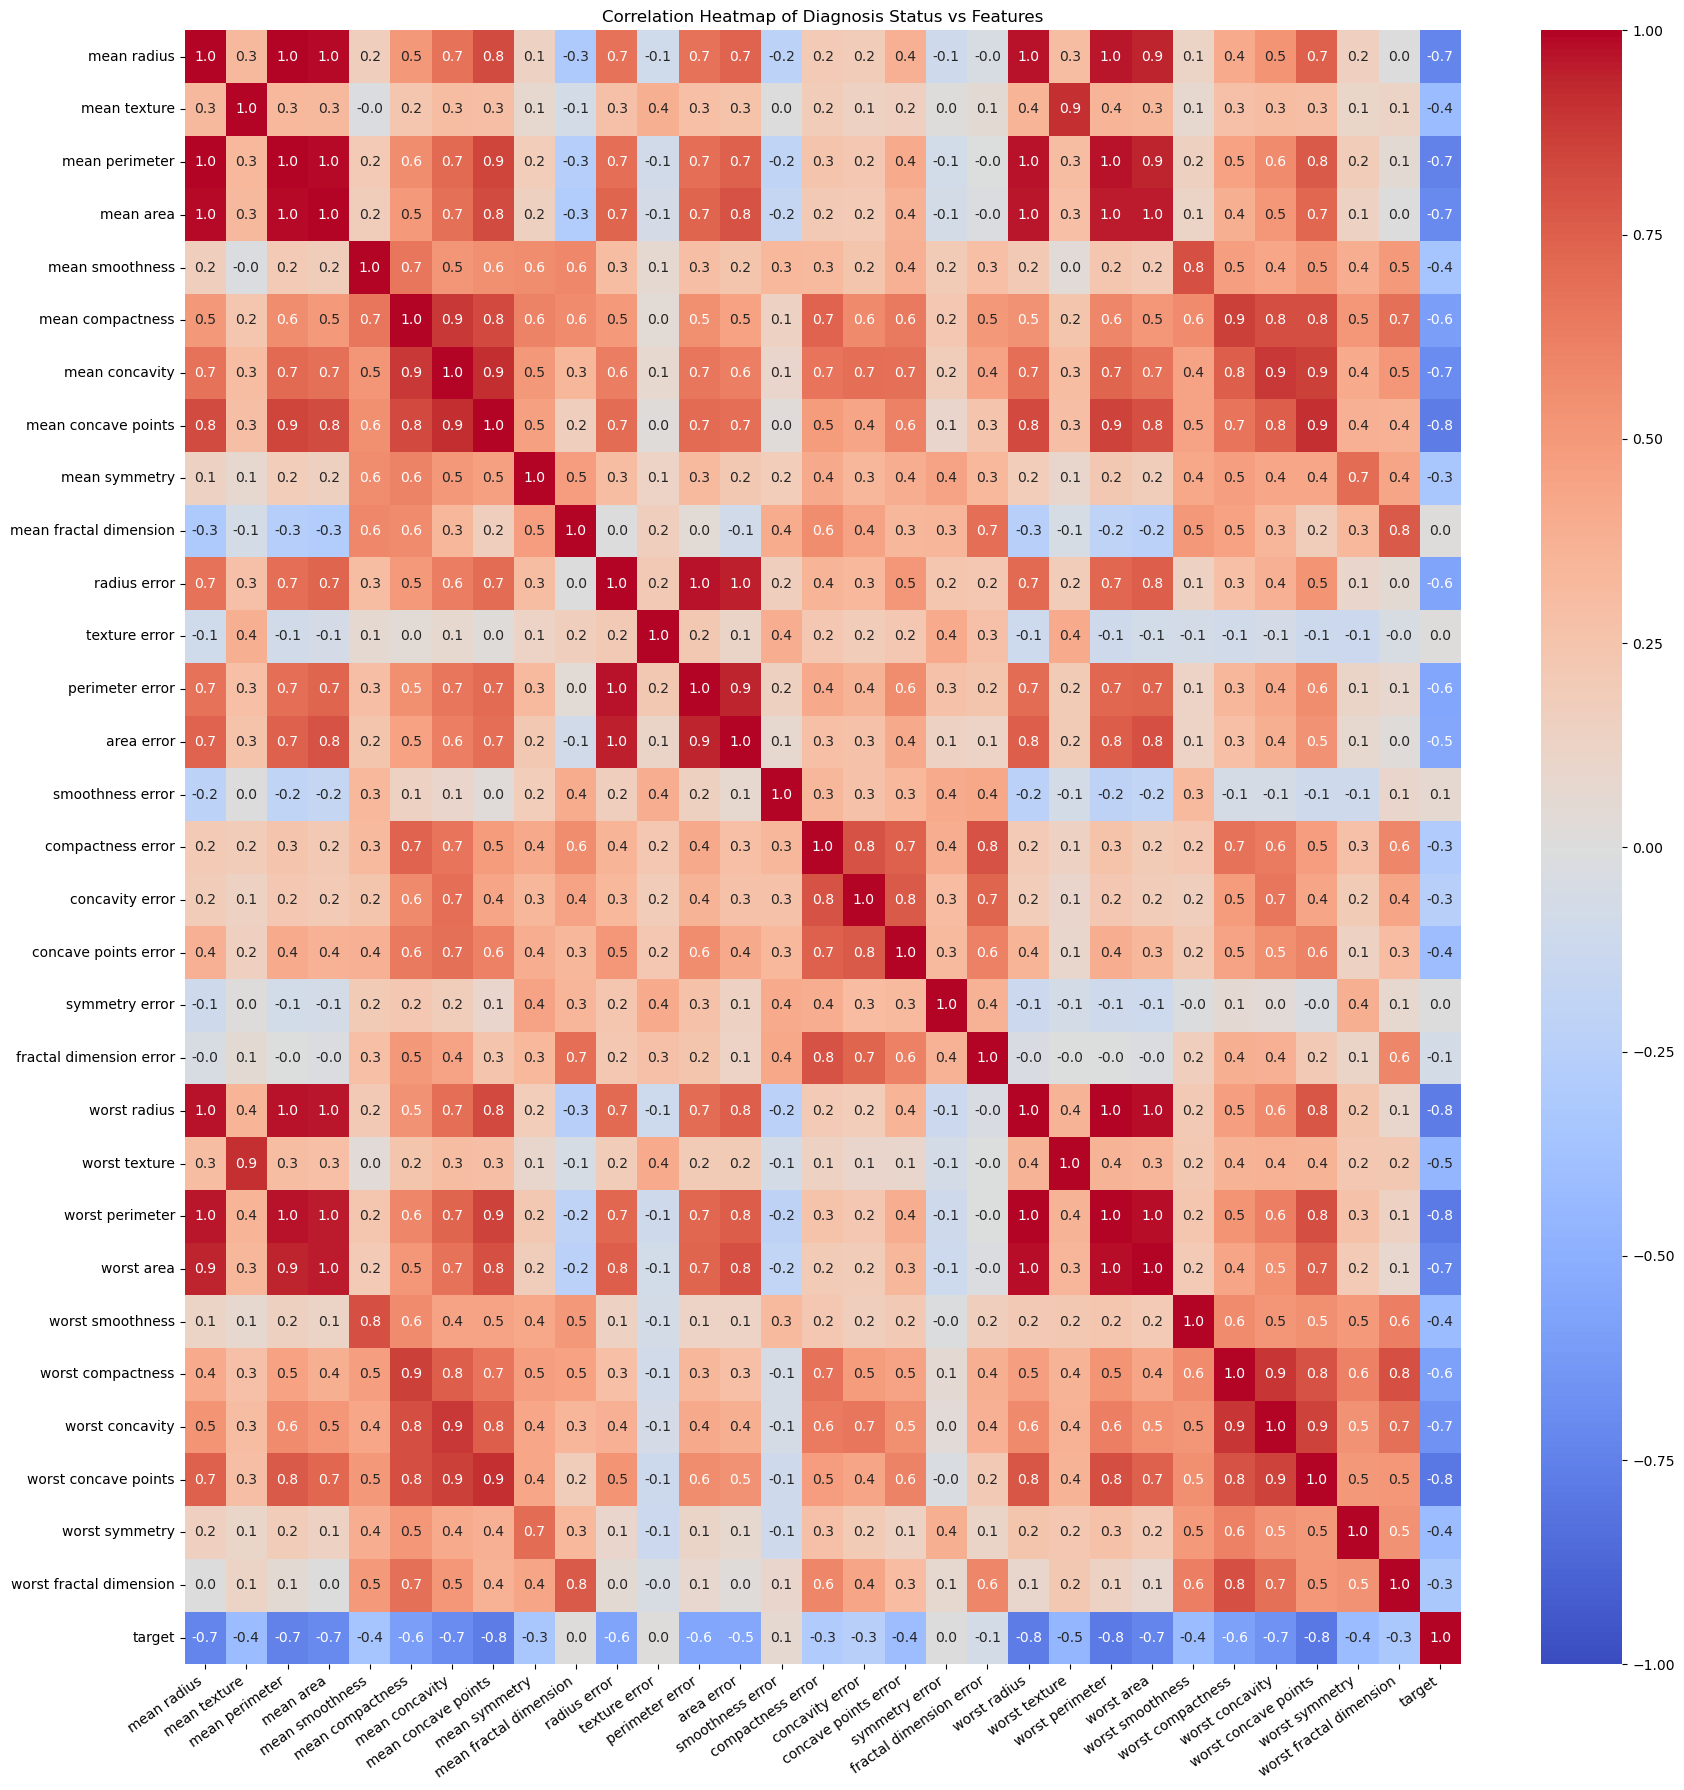


Linear Correlation with Target:
target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.74

In [10]:
# 1. Compute correlation matrix including the target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

# 2. Render the heatmap
plt.figure(figsize=(18, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.1f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Diagnosis Status vs Features')
plt.xticks(rotation=35, ha='right') 
plt.tight_layout()
plt.show()

# 3. Print exact correlation vector sorted to find the strongest signal
print("\nLinear Correlation with Target:")
print(corr_matrix['target'].sort_values(ascending=False))

*** Takeaways:

1/ Strongest Predictors of Malignancy: worst concave points (-0.794), worst perimeter (-0.783), mean concave points (-0.777), and worst radius (-0.776) hold the strongest inverse linear relationships with the target. Larger measurements heavily imply a malignant diagnosis.

2/ Weakest Predictors: symmetry error, texture error, and mean fractal dimension have correlations near zero, indicating virtually no independent linear relationship with tumor severity.

3/ Multicollinearity Warning: When viewing the visual heatmap, we notice intense blocks of red/dark colors showing highly correlated feature clusters (e.g., mean radius, mean perimeter, and mean area correlate near (1.0) with each other). We may want to drop or reduce these redundant features before training models like Logistic Regression.

## Q2 — PCA Scree Plot & Cumulative Variance

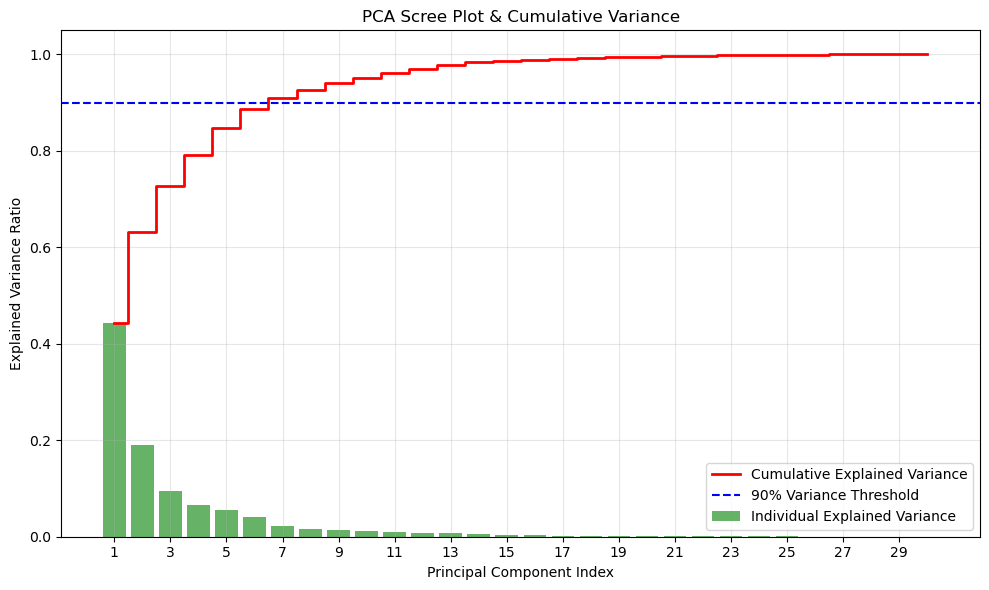

Number of components to explain 90% variance: 7


In [11]:
# 1. Standardize features (essential for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Fit PCA (keeping all components to see the full curve)
pca = PCA()
pca.fit(X_scaled)

exp_var_ratio = pca.explained_variance_ratio_
cum_var_ratio = np.cumsum(exp_var_ratio)

# 3. Render the Scree Plot
plt.figure(figsize=(10, 6))

# Bar plot for individual variance
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.6, 
        color='g', label='Individual Explained Variance')

# Step/Line plot for cumulative variance
plt.step(range(1, len(cum_var_ratio) + 1), cum_var_ratio, where='mid',
         label='Cumulative Explained Variance', color='red', lw=2)

# Aesthetic formatting
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('PCA Scree Plot & Cumulative Variance')
plt.axhline(y=0.90, color='blue', linestyle='--', label='90% Variance Threshold')
plt.xticks(range(1, len(exp_var_ratio) + 1, 2))
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# 4. Print the exact component requirements
n_90 = np.argmax(cum_var_ratio >= 0.90) + 1
print(f"Number of components to explain 90% variance: {n_90}")



*** Takeaways from the plot:

1/ Massive Information Compression: The first 7 principal components cross the blue dashed line, successfully capturing over 90% of the dataset's total variance.

2/ PC1 Dominance: The first component alone contains roughly 44% of the total variance, making it by far the most informative axis.

3/ Diminishing Returns: Beyond the 10th component, individual explained variance (green bars) drops close to zero, showing that features become highly redundant.

## Q3 — 2D PCA Scatter

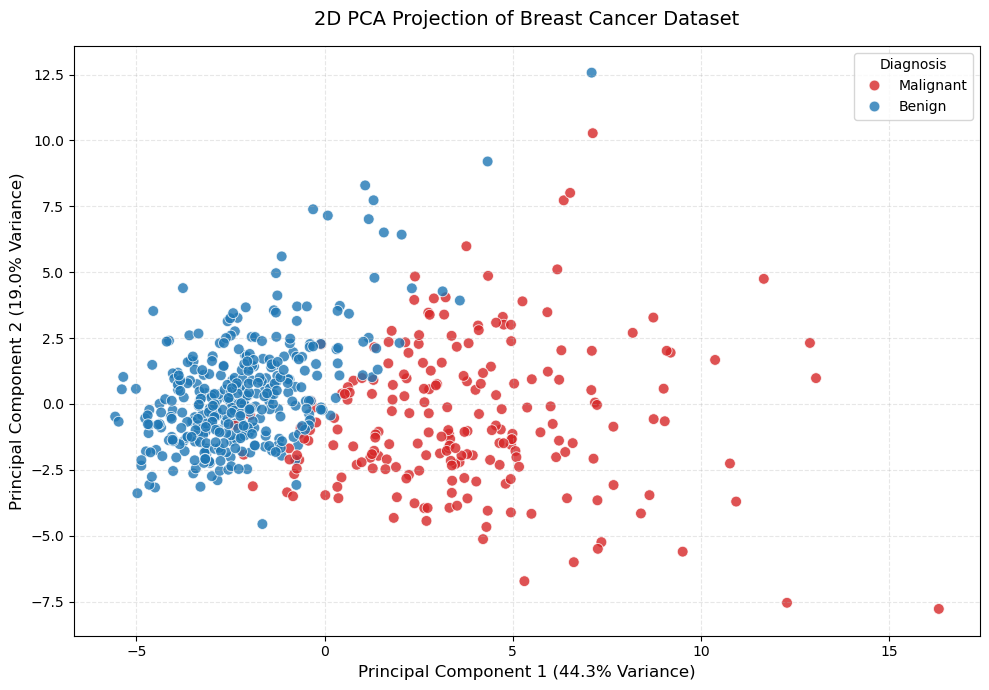

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Standardize and transform to 2 principal components
X_scaled = StandardScaler().fit_transform(X)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# 2. Construct a DataFrame for plotting
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Diagnosis'] = df['diagnosis']  # 'Malignant' or 'Benign'

# 3. Render the 2D Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Diagnosis', 
    palette={'Malignant': '#d62728', 'Benign': '#1f77b4'},
    data=df_pca, 
    alpha=0.8, 
    edgecolor='w', 
    s=60
)

# Extract individual variance percentages for the labels
var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

# Aesthetic formatting
plt.title('2D PCA Projection of Breast Cancer Dataset', fontsize=14, pad=15)
plt.xlabel(f'Principal Component 1 ({var_pc1:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({var_pc2:.1f}% Variance)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='Diagnosis', loc='upper right', frameon=True)
plt.tight_layout()
plt.show()



*** Takeaways from the plot:

1/ Strong Linear Separability: The two diagnostic classes form highly distinct clusters with minimal overlap along the PC1 axis.

2/ Class Variance Differences: Malignant tumors (red) are highly scattered and widespread, whereas benign tumors (blue) are tightly packed together.

3/ PC1 as the Main Discriminator: Moving from left to right along PC1 (44.3% variance) effectively separates the healthy, lower-measurement tissue from the malignant tissue.

## Q4 — Biplot: Feature Loadings

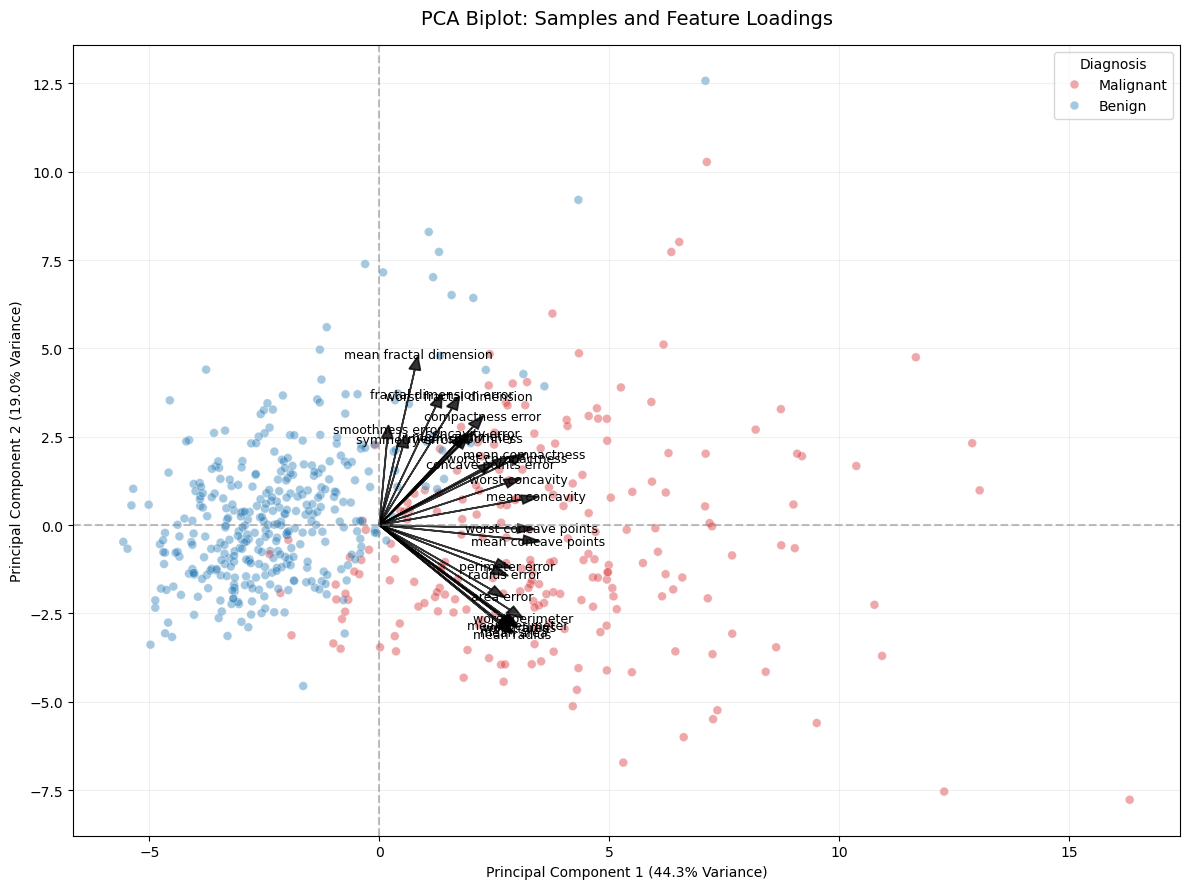

In [ ]:
# 1. Standardize and compute PCA
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Extract loading vectors (components_)
loadings = pca.components_.T  # Shape: (30, 2)

# 3. Render the Biplot
plt.figure(figsize=(12, 9))

# Scatter plot of samples
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], 
    hue=df['diagnosis'], 
    palette={'Malignant': '#d62728', 'Benign': '#1f77b4'},
    alpha=0.4, s=40
)

# Overlay top feature loading vectors (scaling up for visibility)
scale_factor = 12  
feature_names = data.feature_names

# Plotting only the most important features to avoid visual crowding
# Filters for features with substantial magnitude in either PC1 or PC2
for i, feature in enumerate(feature_names):
    if np.abs(loadings[i, 0]) > 0.18 or np.abs(loadings[i, 1]) > 0.18:
        plt.arrow(0, 0, loadings[i, 0] * scale_factor, loadings[i, 1] * scale_factor, 
                  color='black', alpha=0.8, head_width=0.25, lw=1.2)
        plt.text(loadings[i, 0] * scale_factor * 1.1, loadings[i, 1] * scale_factor * 1.1, 
                 feature, color='black', ha='center', va='center', fontsize=9)

# Aesthetic formatting
plt.title('PCA Biplot: Samples and Feature Loadings', fontsize=14, pad=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.2)
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

*** Takeaways fromt the plot:

1/ Malignancy Drivers: The vast majority of feature vectors point to the right toward the Malignant cluster, confirming that increases in features like size, perimeter, and radius strongly pull samples into the malignant zone.

2/ PC1 Size Groupings: Size-related features (mean perimeter, mean radius, worst area) cluster tightly along the bottom-right vector group, strongly influencing negative PC2 values and positive PC1 values.

3/ PC2 Shape/Error Influence: Vectors pointing upward toward positive PC2 values consist largely of shape complexity and error metrics (mean fractal dimension, compactness error), capturing structural variation independent of tumor size.

## Q5 — Raw vs PCA Features: Classification Accuracy

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Split the original data into Train/Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Standardize features based strictly on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model 1: Train on RAW Scaled Features (All 30 dimensions)
clf_raw = LogisticRegression(random_state=42)
clf_raw.fit(X_train_scaled, y_train)
y_pred_raw = clf_raw.predict(X_test_scaled)
acc_raw = accuracy_score(y_test, y_pred_raw)

# 4. Transform data using PCA (Keeping top 7 components to capture ~90% variance)
pca = PCA(n_components=7, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 5. Model 2: Train on PCA Components (Only 7 dimensions)
clf_pca = LogisticRegression(random_state=42)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

# 6. Display performance results
print("="*45)
print(f"Raw Features Model Accuracy (30 dims): {acc_raw:.4f}")
print(f"PCA Features Model Accuracy (7 dims):  {acc_pca:.4f}")
print(f"Dimension Reduction Ratio:            {30/7:.1f}x reduction")
print("="*45)


Raw Features Model Accuracy (30 dims): 0.9883
PCA Features Model Accuracy (7 dims):  0.9591
Dimension Reduction Ratio:            4.3x reduction


1/ High Information Retention: Compressing your feature space by 4.3x only resulted in a minor performance drop of about 2.9%, confirming the PCA effectively captured the core diagnostic signals.

2/ Near-Perfect Raw Baseline: The raw model's exceptional accuracy (98.83%) highlights that the original 30 scaled features contain highly distinct, linearly separable patterns for tumor classification.

3/ Efficiency vs. Accuracy Trade-off: While the raw model is ideal if maximizing accuracy is your only priority, the 7-dimensional PCA model offers a much smaller footprint, reducing risks of overfitting and lowering computing costs for larger deployment pipelines.